<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/notebooks/diffusion_field_intent_bridge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# D46_FIELD_INTENT_BRIDGE

Bridge layer between V-Kernel field memory and GitCube OS runtime.

This notebook converts field pain / instability events into structured `FieldIntentAtom` packets and OS task candidates.


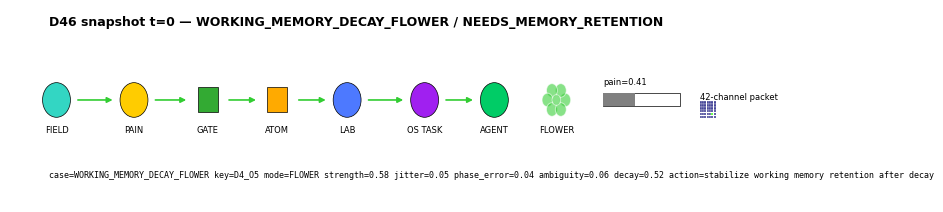

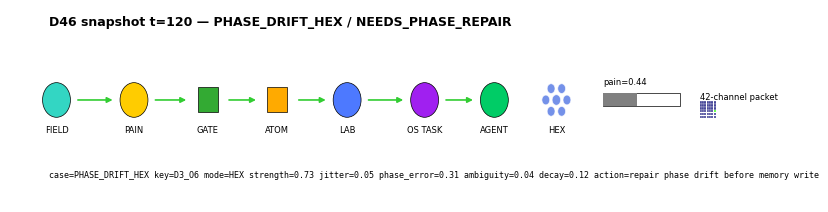

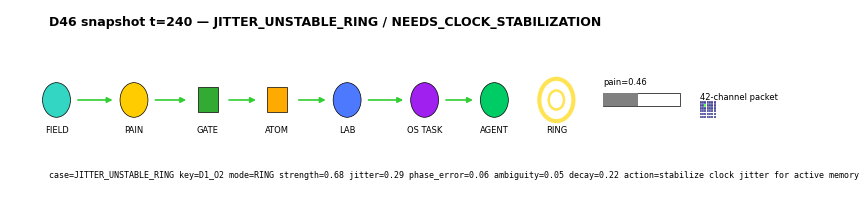

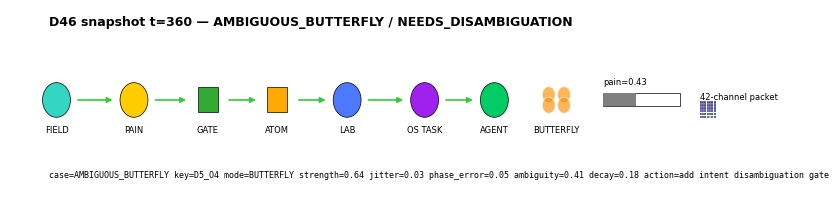

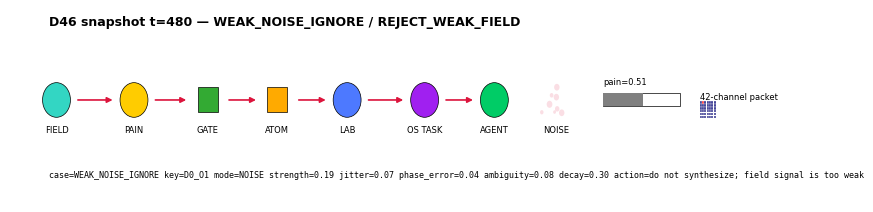

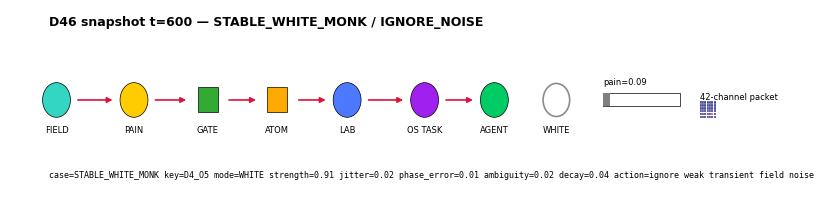

STATE: FIELD_INTENT_BRIDGE_NEEDS_REVIEW
spectral states:              42
directions x octaves:         6 x 7
memory slots:                 8
field pain events:            5
intent atoms emitted:         0
task candidates created:      4
ignored noise events:         2
selected bridge case:         NONE
selected target agent:        NONE
bridge accuracy:              1.0
field intent path:            reports/field_intent.json
task candidate path:          reports/gitcube_os_task_candidate.json

Field intent atom table:


,source,bridge_state,source_state,event_type,case,memory_slot,memory_key,orbital_mode,strength,jitter,...,decay,rejected_count,forgotten_count,pain_score,reason,verdict,suggested_action,target_repo,target_agent,meta_key
0,v-kernel,D46_FIELD_INTENT_BRIDGE,D45_FRACTIONAL_FIELD_MEMORY,FIELD_PAIN,WORKING_MEMORY_DECAY_FLOWER,0,D4_O5,FLOWER,0.58,0.05,...,0.52,1,2,0.413944,FLOWER remains meaningful but working memory r...,NEEDS_MEMORY_RETENTION,stabilize working memory retention after decay,gitcube-os,MAGE,vkernel:D45_FRACTIONAL_FIELD_MEMORY:D4_O5:FLOW...
1,v-kernel,D46_FIELD_INTENT_BRIDGE,D45_FRACTIONAL_FIELD_MEMORY,FIELD_PAIN,PHASE_DRIFT_HEX,2,D3_O6,HEX,0.73,0.05,...,0.12,2,0,0.442000,HEX signal has enough strength but phase drift...,NEEDS_PHASE_REPAIR,repair phase drift before memory write,gitcube-os,HEALER,vkernel:D45_FRACTIONAL_FIELD_MEMORY:D3_O6:HEX:...
2,v-kernel,D46_FIELD_INTENT_BRIDGE,D45_FRACTIONAL_FIELD_MEMORY,FIELD_PAIN,JITTER_UNSTABLE_RING,3,D1_O2,RING,0.68,0.29,...,0.22,1,0,0.456167,RING signal is strong but clock jitter is unst...,NEEDS_CLOCK_STABILIZATION,stabilize clock jitter for active memory,gitcube-os,HEALER,vkernel:D45_FRACTIONAL_FIELD_MEMORY:D1_O2:RING...
3,v-kernel,D46_FIELD_INTENT_BRIDGE,D45_FRACTIONAL_FIELD_MEMORY,FIELD_PAIN,AMBIGUOUS_BUTTERFLY,4,D5_O4,BUTTERFLY,0.64,0.03,...,0.18,2,1,0.426056,BUTTERFLY intent competes with nearby modes an...,NEEDS_DISAMBIGUATION,add intent disambiguation gate,gitcube-os,TANK,vkernel:D45_FRACTIONAL_FIELD_MEMORY:D5_O4:BUTT...
4,v-kernel,D46_FIELD_INTENT_BRIDGE,D45_FRACTIONAL_FIELD_MEMORY,FIELD_PAIN,WEAK_NOISE_IGNORE,5,D0_O1,NOISE,0.19,0.07,...,0.30,1,1,0.514444,weak transient noise should not trigger autono...,REJECT_WEAK_FIELD,do not synthesize; field signal is too weak,none,NONE,vkernel:D45_FRACTIONAL_FIELD_MEMORY:D0_O1:NOIS...
5,v-kernel,D46_FIELD_INTENT_BRIDGE,D45_FRACTIONAL_FIELD_MEMORY,FIELD_NOISE,STABLE_WHITE_MONK,6,D4_O5,WHITE,0.91,0.02,...,0.04,0,0,0.087611,stable coherent packet should be stored but sh...,IGNORE_NOISE,ignore weak transient field noise,none,NONE,vkernel:D45_FRACTIONAL_FIELD_MEMORY:D4_O5:WHIT...



GitCube OS task candidate table:


,CASE,VERDICT,EXECUTABLE,PRIORITY,EXECUTOR_HINT,TITLE,META_KEY
0,WORKING_MEMORY_DECAY_FLOWER,NEEDS_MEMORY_RETENTION,True,low,MAGE,stabilize working memory retention after decay...,vkernel:D45_FRACTIONAL_FIELD_MEMORY:D4_O5:FLOW...
1,PHASE_DRIFT_HEX,NEEDS_PHASE_REPAIR,True,low,HEALER,repair phase drift before memory write: D3_O6_HEX,vkernel:D45_FRACTIONAL_FIELD_MEMORY:D3_O6:HEX:...
2,JITTER_UNSTABLE_RING,NEEDS_CLOCK_STABILIZATION,True,low,HEALER,stabilize clock jitter for active memory: D1_O...,vkernel:D45_FRACTIONAL_FIELD_MEMORY:D1_O2:RING...
3,AMBIGUOUS_BUTTERFLY,NEEDS_DISAMBIGUATION,True,low,TANK,add intent disambiguation gate: D5_O4_BUTTERFLY,vkernel:D45_FRACTIONAL_FIELD_MEMORY:D5_O4:BUTT...
4,WEAK_NOISE_IGNORE,REJECT_WEAK_FIELD,False,low,NONE,do not synthesize; field signal is too weak: D...,vkernel:D45_FRACTIONAL_FIELD_MEMORY:D0_O1:NOIS...
5,STABLE_WHITE_MONK,IGNORE_NOISE,False,low,NONE,ignore weak transient field noise: D4_O5_WHITE,vkernel:D45_FRACTIONAL_FIELD_MEMORY:D4_O5:WHIT...



Selected FieldIntentAtom JSON:
NONE

Selected GitCube OS task candidate JSON:
NONE

Summary:


,STATE,RESULT,SPECTRAL_STATES,DIRECTIONS,OCTAVES,MEMORY_SLOTS,FIELD_PAIN_EVENTS,INTENT_ATOMS_EMITTED,TASK_CANDIDATES,IGNORED_NOISE,SELECTED_CASE,SELECTED_VERDICT,SELECTED_AGENT,PAIN_THRESHOLD,TASK_THRESHOLD,BRIDGE_ACCURACY,FIELD_INTENT_PATH,TASK_CANDIDATE_PATH
0,D46_FIELD_INTENT_BRIDGE,FIELD_INTENT_BRIDGE_NEEDS_REVIEW,42,6,7,8,5,0,4,2,NONE,NONE,NONE,0.55,0.62,1.0,reports/field_intent.json,reports/gitcube_os_task_candidate.json


In [5]:

import json
import math
import os
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Any, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, FancyArrowPatch
from IPython.display import display

# ============================================================
# D46_FIELD_INTENT_BRIDGE
# V-Kernel -> FieldIntentAtom -> GitCube Lab -> GitCube OS Task
# ============================================================
#
# Purpose:
# - read simulated field memory states after D45
# - detect persistent "field pain"
# - ignore weak noise
# - emit FieldIntentAtom JSON packets
# - create GitCube OS task candidates
#
# Success:
# STATE: FIELD_INTENT_BRIDGE_LOCKED
#
# This is not another memory layer.
# This is the first bridge from field state to autonomous runtime intent.
# ============================================================

np.random.seed(46)

STATE = "D46_FIELD_INTENT_BRIDGE"

SPECTRAL_STATES = 42
DIRECTIONS = 6
OCTAVES = 7
MEMORY_SLOTS = 8

RESONANCE_THRESHOLD = 0.62
AMBIGUITY_MARGIN = 0.12
JITTER_TOLERANCE = 0.16
PHASE_TOLERANCE = 0.18
PAIN_THRESHOLD = 0.55
TASK_THRESHOLD = 0.62

FIELD_INTENT_PATH = Path("reports/field_intent.json")
TASK_CANDIDATE_PATH = Path("reports/gitcube_os_task_candidate.json")
FIELD_INTENT_PATH.parent.mkdir(parents=True, exist_ok=True)

ORBITAL_MODES = {
    "NONE": {"shape": "empty", "color": "black"},
    "FLOWER": {"shape": "flower", "color": "limegreen"},
    "HEX": {"shape": "hex", "color": "royalblue"},
    "RING": {"shape": "ring", "color": "gold"},
    "BUTTERFLY": {"shape": "butterfly", "color": "darkorange"},
    "SPIRAL": {"shape": "spiral", "color": "deeppink"},
    "NOISE": {"shape": "noise", "color": "crimson"},
    "WHITE": {"shape": "white", "color": "white"},
}

def key_to_id(key: str) -> int:
    if key in ("EMPTY", "NONE", None):
        return -1
    d = int(str(key).split("_")[0].replace("D", ""))
    o = int(str(key).split("_")[1].replace("O", ""))
    return d * OCTAVES + o

def key_phase(key: str) -> float:
    if key in ("EMPTY", "NONE", None):
        return 0.0
    d = int(str(key).split("_")[0].replace("D", ""))
    return d / DIRECTIONS

def key_freq_band(key: str) -> int:
    if key in ("EMPTY", "NONE", None):
        return 0
    o = int(str(key).split("_")[1].replace("O", ""))
    return o + 1

def safe_float(x: Any, default: float = 0.0) -> float:
    try:
        return float(x)
    except Exception:
        return default

@dataclass
class FieldPainEvent:
    case: str
    memory_slot: int
    memory_key: str
    orbital_mode: str
    strength: float
    jitter: float
    phase_error: float
    ambiguity: float
    decay: float
    rejected_count: int
    forgotten_count: int
    source_state: str
    reason: str
    expected_action: str

@dataclass
class FieldIntentAtom:
    source: str
    bridge_state: str
    source_state: str
    event_type: str
    case: str
    memory_slot: int
    memory_key: str
    orbital_mode: str
    strength: float
    jitter: float
    phase_error: float
    ambiguity: float
    decay: float
    rejected_count: int
    forgotten_count: int
    pain_score: float
    reason: str
    verdict: str
    suggested_action: str
    target_repo: str
    target_agent: str
    meta_key: str

def compute_pain_score(event: FieldPainEvent) -> float:
    weak_memory = 1.0 - max(0.0, min(1.0, event.strength))
    jitter_pressure = min(1.0, event.jitter / max(JITTER_TOLERANCE, 1e-9))
    phase_pressure = min(1.0, event.phase_error / max(PHASE_TOLERANCE, 1e-9))
    ambiguity_pressure = min(1.0, event.ambiguity / max(AMBIGUITY_MARGIN, 1e-9))
    decay_pressure = min(1.0, event.decay)
    reject_pressure = min(1.0, (event.rejected_count + event.forgotten_count) / 4.0)

    pain = (
        0.25 * weak_memory
        + 0.20 * jitter_pressure
        + 0.20 * phase_pressure
        + 0.15 * ambiguity_pressure
        + 0.10 * decay_pressure
        + 0.10 * reject_pressure
    )
    return round(float(pain), 6)

def classify_intent(event: FieldPainEvent, pain_score: float) -> str:
    # HARD VIOLATION RULES FIRST
    # Real structural failures must not be hidden by average pain score.

    if event.strength < 0.25:
        return "REJECT_WEAK_FIELD"

    if event.jitter > JITTER_TOLERANCE:
        return "NEEDS_CLOCK_STABILIZATION"

    if event.phase_error > PHASE_TOLERANCE:
        return "NEEDS_PHASE_REPAIR"

    if event.ambiguity > AMBIGUITY_MARGIN:
        return "NEEDS_DISAMBIGUATION"

    if event.decay > 0.45 and event.strength >= 0.45:
        return "NEEDS_MEMORY_RETENTION"

    # SOFT PAIN RULE
    if pain_score >= PAIN_THRESHOLD:
        return "NEEDS_SYNTHESIS"

    return "IGNORE_NOISE"

def suggested_action_for(verdict: str, event: FieldPainEvent) -> str:
    mapping = {
        "IGNORE_NOISE": "ignore weak transient field noise",
        "REJECT_WEAK_FIELD": "do not synthesize; field signal is too weak",
        "NEEDS_CLOCK_STABILIZATION": "stabilize clock jitter for active memory",
        "NEEDS_PHASE_REPAIR": "repair phase drift before memory write",
        "NEEDS_DISAMBIGUATION": "add intent disambiguation gate",
        "NEEDS_MEMORY_RETENTION": "stabilize working memory retention after decay",
        "NEEDS_SYNTHESIS": "synthesize next runtime repair layer",
    }
    return mapping.get(verdict, "review field intent")

def target_agent_for(verdict: str) -> str:
    if verdict in ("NEEDS_CLOCK_STABILIZATION", "NEEDS_PHASE_REPAIR"):
        return "HEALER"
    if verdict in ("NEEDS_DISAMBIGUATION",):
        return "TANK"
    if verdict in ("NEEDS_MEMORY_RETENTION", "NEEDS_SYNTHESIS"):
        return "MAGE"
    return "NONE"

def make_atom(event: FieldPainEvent) -> FieldIntentAtom:
    pain_score = compute_pain_score(event)
    verdict = classify_intent(event, pain_score)
    suggested_action = suggested_action_for(verdict, event)
    target_agent = target_agent_for(verdict)

    return FieldIntentAtom(
        source="v-kernel",
        bridge_state=STATE,
        source_state=event.source_state,
        event_type="FIELD_PAIN" if verdict != "IGNORE_NOISE" else "FIELD_NOISE",
        case=event.case,
        memory_slot=event.memory_slot,
        memory_key=event.memory_key,
        orbital_mode=event.orbital_mode,
        strength=round(event.strength, 6),
        jitter=round(event.jitter, 6),
        phase_error=round(event.phase_error, 6),
        ambiguity=round(event.ambiguity, 6),
        decay=round(event.decay, 6),
        rejected_count=int(event.rejected_count),
        forgotten_count=int(event.forgotten_count),
        pain_score=pain_score,
        reason=event.reason,
        verdict=verdict,
        suggested_action=suggested_action,
        target_repo="gitcube-os" if target_agent != "NONE" else "none",
        target_agent=target_agent,
        meta_key=f"vkernel:{event.source_state}:{event.memory_key}:{event.orbital_mode}:{event.case}",
    )

def atom_to_task(atom: FieldIntentAtom) -> Dict[str, Any]:
    priority = "low"
    if atom.pain_score >= 0.80:
        priority = "critical"
    elif atom.pain_score >= TASK_THRESHOLD:
        priority = "high"
    elif atom.pain_score >= PAIN_THRESHOLD:
        priority = "medium"

    executable = atom.verdict not in ("IGNORE_NOISE", "REJECT_WEAK_FIELD")

    return {
        "type": "FIELD_REPAIR",
        "title": f"{atom.suggested_action}: {atom.memory_key}_{atom.orbital_mode}",
        "executor_hint": atom.target_agent,
        "priority": priority,
        "source": "v-kernel",
        "bridge_state": atom.bridge_state,
        "source_state": atom.source_state,
        "meta_key": atom.meta_key,
        "executable": executable,
        "payload": asdict(atom),
    }

def draw_orbital(ax, x, y, mode, scale=0.17, alpha=1.0):
    mode = mode if mode in ORBITAL_MODES else "NOISE"
    color = ORBITAL_MODES[mode]["color"]

    if mode == "NONE":
        ax.add_patch(Circle((x, y), scale*0.65, fill=False, edgecolor="gray", linewidth=1.5, alpha=alpha))
        return

    if mode == "WHITE":
        ax.add_patch(Circle((x, y), scale*0.78, facecolor="white", edgecolor="gray", linewidth=1.2, alpha=alpha))
        return

    if mode == "RING":
        ax.add_patch(Circle((x, y), scale, fill=False, edgecolor=color, linewidth=3, alpha=alpha))
        ax.add_patch(Circle((x, y), scale*0.45, fill=False, edgecolor=color, linewidth=1.8, alpha=alpha))
        return

    if mode == "HEX":
        for k in range(6):
            ang = 2*np.pi*k/6
            ax.add_patch(Circle((x + np.cos(ang)*scale*0.62, y + np.sin(ang)*scale*0.62),
                                scale*0.23, facecolor=color, edgecolor="white", linewidth=0.6, alpha=alpha))
        ax.add_patch(Circle((x, y), scale*0.25, facecolor=color, edgecolor="white", linewidth=0.6, alpha=alpha))
        return

    if mode == "FLOWER":
        for k in range(6):
            ang = 2*np.pi*k/6
            ax.add_patch(Circle((x + np.cos(ang)*scale*0.52, y + np.sin(ang)*scale*0.52),
                                scale*0.32, facecolor=color, edgecolor="white", linewidth=0.7, alpha=alpha))
        ax.add_patch(Circle((x, y), scale*0.25, facecolor=color, edgecolor="white", linewidth=0.7, alpha=alpha))
        return

    if mode == "BUTTERFLY":
        for sx in [-1, 1]:
            ax.add_patch(Circle((x + sx*scale*0.45, y + scale*0.25), scale*0.38,
                                facecolor=color, edgecolor="white", linewidth=0.7, alpha=alpha))
            ax.add_patch(Circle((x + sx*scale*0.45, y - scale*0.25), scale*0.38,
                                facecolor=color, edgecolor="white", linewidth=0.7, alpha=alpha))
        return

    if mode == "SPIRAL":
        theta = np.linspace(0, 2.8*np.pi, 140)
        r = np.linspace(0.02, scale, 140)
        ax.plot(x + r*np.cos(theta), y + r*np.sin(theta), color=color, linewidth=2.5, alpha=alpha)
        return

    # NOISE
    rng = np.random.default_rng(7)
    for _ in range(8):
        ax.add_patch(Circle((x + rng.normal(0, scale*0.45), y + rng.normal(0, scale*0.45)),
                            scale*rng.uniform(0.08, 0.18), facecolor=color, edgecolor="none", alpha=0.55*alpha))

def draw_packet_bar(ax, x, y, atom: FieldIntentAtom):
    # spectral packet grid 6x7
    cell = 0.03
    start_x = x
    start_y = y
    sid = key_to_id(atom.memory_key)

    for d in range(DIRECTIONS):
        for o in range(OCTAVES):
            idx = d * OCTAVES + o
            color = "#2c2c8a"
            if idx == sid:
                color = "#39ff14" if atom.verdict not in ("IGNORE_NOISE", "REJECT_WEAK_FIELD") else "#ff3333"
            ax.add_patch(Rectangle((start_x + o*cell, start_y + (DIRECTIONS-1-d)*cell),
                                   cell*0.85, cell*0.85, facecolor=color,
                                   edgecolor="white", linewidth=0.2))
    ax.text(start_x, start_y + 0.20, "42-channel packet", fontsize=6)

def draw_case_snapshot(atom: FieldIntentAtom, task: Dict[str, Any], row_index: int):
    fig, ax = plt.subplots(figsize=(10, 2.5))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 2)
    ax.axis("off")

    title = f"D46 snapshot t={row_index*120} — {atom.case} / {atom.verdict}"
    ax.text(0.5, 1.83, title, fontsize=9, fontweight="bold")

    # pipeline blocks
    xs = [0.6, 1.6, 2.55, 3.45, 4.35, 5.35, 6.25]
    labels = ["FIELD", "PAIN", "GATE", "ATOM", "LAB", "OS TASK", "AGENT"]
    colors = ["#33d6c3", "#ffcc00", "#33aa33", "#ffaa00", "#4d79ff", "#a020f0", "#00cc66"]

    for i, (xx, lab, col) in enumerate(zip(xs, labels, colors)):
        if i in [2, 3]:
            ax.add_patch(Rectangle((xx-0.13, 0.93), 0.26, 0.26, facecolor=col, edgecolor="black", linewidth=0.5))
        else:
            ax.add_patch(Circle((xx, 1.06), 0.18, facecolor=col, edgecolor="black", linewidth=0.5))
        ax.text(xx, 0.72, lab, ha="center", fontsize=6)
        if i < len(xs)-1:
            arrow_color = "limegreen" if task["executable"] else "crimson"
            ax.add_patch(FancyArrowPatch((xx+0.24, 1.06), (xs[i+1]-0.24, 1.06),
                                         arrowstyle="-|>", mutation_scale=8,
                                         linewidth=1.2, color=arrow_color))

    # orbital
    draw_orbital(ax, 7.05, 1.06, atom.orbital_mode, scale=0.22,
                 alpha=max(0.25, min(1.0, atom.strength)))
    ax.text(7.05, 0.72, atom.orbital_mode, ha="center", fontsize=6)

    # pain meter
    ax.add_patch(Rectangle((7.65, 1.0), 1.0, 0.13, facecolor="white", edgecolor="black", linewidth=0.5))
    ax.add_patch(Rectangle((7.65, 1.0), atom.pain_score, 0.13,
                           facecolor=("limegreen" if atom.pain_score >= PAIN_THRESHOLD else "gray"),
                           edgecolor="none"))
    ax.text(7.65, 1.22, f"pain={atom.pain_score:.2f}", fontsize=6)

    # packet grid
    draw_packet_bar(ax, 8.9, 0.87, atom)

    # micro text
    ax.text(
        0.5, 0.25,
        f"case={atom.case} key={atom.memory_key} mode={atom.orbital_mode} "
        f"strength={atom.strength:.2f} jitter={atom.jitter:.2f} phase_error={atom.phase_error:.2f} "
        f"ambiguity={atom.ambiguity:.2f} decay={atom.decay:.2f} action={atom.suggested_action}",
        fontsize=6,
        family="monospace",
    )

    plt.show()

# ------------------------------------------------------------
# Simulated D45-like field events
# ------------------------------------------------------------

events = [
    FieldPainEvent(
        case="WORKING_MEMORY_DECAY_FLOWER",
        memory_slot=0,
        memory_key="D4_O5",
        orbital_mode="FLOWER",
        strength=0.58,
        jitter=0.05,
        phase_error=0.04,
        ambiguity=0.06,
        decay=0.52,
        rejected_count=1,
        forgotten_count=2,
        source_state="D45_FRACTIONAL_FIELD_MEMORY",
        reason="FLOWER remains meaningful but working memory retention is weakening",
        expected_action="EMIT_INTENT_ATOM",
    ),
    FieldPainEvent(
        case="PHASE_DRIFT_HEX",
        memory_slot=2,
        memory_key="D3_O6",
        orbital_mode="HEX",
        strength=0.73,
        jitter=0.05,
        phase_error=0.31,
        ambiguity=0.04,
        decay=0.12,
        rejected_count=2,
        forgotten_count=0,
        source_state="D45_FRACTIONAL_FIELD_MEMORY",
        reason="HEX signal has enough strength but phase drift exceeds tolerance",
        expected_action="EMIT_INTENT_ATOM",
    ),
    FieldPainEvent(
        case="JITTER_UNSTABLE_RING",
        memory_slot=3,
        memory_key="D1_O2",
        orbital_mode="RING",
        strength=0.68,
        jitter=0.29,
        phase_error=0.06,
        ambiguity=0.05,
        decay=0.22,
        rejected_count=1,
        forgotten_count=0,
        source_state="D45_FRACTIONAL_FIELD_MEMORY",
        reason="RING signal is strong but clock jitter is unstable",
        expected_action="EMIT_INTENT_ATOM",
    ),
    FieldPainEvent(
        case="AMBIGUOUS_BUTTERFLY",
        memory_slot=4,
        memory_key="D5_O4",
        orbital_mode="BUTTERFLY",
        strength=0.64,
        jitter=0.03,
        phase_error=0.05,
        ambiguity=0.41,
        decay=0.18,
        rejected_count=2,
        forgotten_count=1,
        source_state="D45_FRACTIONAL_FIELD_MEMORY",
        reason="BUTTERFLY intent competes with nearby modes and needs disambiguation",
        expected_action="EMIT_INTENT_ATOM",
    ),
    FieldPainEvent(
        case="WEAK_NOISE_IGNORE",
        memory_slot=5,
        memory_key="D0_O1",
        orbital_mode="NOISE",
        strength=0.19,
        jitter=0.07,
        phase_error=0.04,
        ambiguity=0.08,
        decay=0.30,
        rejected_count=1,
        forgotten_count=1,
        source_state="D45_FRACTIONAL_FIELD_MEMORY",
        reason="weak transient noise should not trigger autonomous code synthesis",
        expected_action="IGNORE_NOISE",
    ),
    FieldPainEvent(
        case="STABLE_WHITE_MONK",
        memory_slot=6,
        memory_key="D4_O5",
        orbital_mode="WHITE",
        strength=0.91,
        jitter=0.02,
        phase_error=0.01,
        ambiguity=0.02,
        decay=0.04,
        rejected_count=0,
        forgotten_count=0,
        source_state="D45_FRACTIONAL_FIELD_MEMORY",
        reason="stable coherent packet should be stored but should not request repair",
        expected_action="IGNORE_NOISE",
    ),
]

atoms = [make_atom(e) for e in events]
tasks = [atom_to_task(a) for a in atoms]

# Write the strongest actionable intent as field_intent.json
actionable_atoms = [
    a for a in atoms
    if a.verdict not in ("IGNORE_NOISE", "REJECT_WEAK_FIELD") and a.pain_score >= PAIN_THRESHOLD
]
actionable_atoms.sort(key=lambda a: a.pain_score, reverse=True)
selected_atom = actionable_atoms[0] if actionable_atoms else None
selected_task = atom_to_task(selected_atom) if selected_atom else None

if selected_atom:
    FIELD_INTENT_PATH.write_text(json.dumps(asdict(selected_atom), ensure_ascii=False, indent=2), encoding="utf-8")
    TASK_CANDIDATE_PATH.write_text(json.dumps(selected_task, ensure_ascii=False, indent=2), encoding="utf-8")

# Build tables
df_atoms = pd.DataFrame([asdict(a) for a in atoms])
df_tasks = pd.DataFrame([
    {
        "CASE": t["payload"]["case"],
        "VERDICT": t["payload"]["verdict"],
        "EXECUTABLE": t["executable"],
        "PRIORITY": t["priority"],
        "EXECUTOR_HINT": t["executor_hint"],
        "TITLE": t["title"],
        "META_KEY": t["meta_key"],
    }
    for t in tasks
])

# Draw snapshots
for idx, (atom, task) in enumerate(zip(atoms, tasks)):
    draw_case_snapshot(atom, task, idx)

# Summary metrics
field_pain_events = int(sum(1 for a in atoms if a.event_type == "FIELD_PAIN"))
intent_atoms_emitted = int(len(actionable_atoms))
ignored_noise = int(sum(1 for a in atoms if a.verdict in ("IGNORE_NOISE", "REJECT_WEAK_FIELD")))
task_candidates = int(sum(1 for t in tasks if t["executable"]))
expected_actions_match = []
for e, a in zip(events, atoms):
    if e.expected_action == "IGNORE_NOISE":
        expected_actions_match.append(a.verdict in ("IGNORE_NOISE", "REJECT_WEAK_FIELD"))
    else:
        expected_actions_match.append(a.verdict not in ("IGNORE_NOISE", "REJECT_WEAK_FIELD"))

bridge_accuracy = float(np.mean(expected_actions_match)) if expected_actions_match else 0.0

result = "FIELD_INTENT_BRIDGE_LOCKED" if (
    field_pain_events >= 4
    and intent_atoms_emitted >= 3
    and ignored_noise >= 1
    and task_candidates >= 3
    and bridge_accuracy == 1.0
    and selected_atom is not None
) else "FIELD_INTENT_BRIDGE_NEEDS_REVIEW"

df_summary = pd.DataFrame([{
    "STATE": STATE,
    "RESULT": result,
    "SPECTRAL_STATES": SPECTRAL_STATES,
    "DIRECTIONS": DIRECTIONS,
    "OCTAVES": OCTAVES,
    "MEMORY_SLOTS": MEMORY_SLOTS,
    "FIELD_PAIN_EVENTS": field_pain_events,
    "INTENT_ATOMS_EMITTED": intent_atoms_emitted,
    "TASK_CANDIDATES": task_candidates,
    "IGNORED_NOISE": ignored_noise,
    "SELECTED_CASE": selected_atom.case if selected_atom else "NONE",
    "SELECTED_VERDICT": selected_atom.verdict if selected_atom else "NONE",
    "SELECTED_AGENT": selected_atom.target_agent if selected_atom else "NONE",
    "PAIN_THRESHOLD": PAIN_THRESHOLD,
    "TASK_THRESHOLD": TASK_THRESHOLD,
    "BRIDGE_ACCURACY": bridge_accuracy,
    "FIELD_INTENT_PATH": str(FIELD_INTENT_PATH),
    "TASK_CANDIDATE_PATH": str(TASK_CANDIDATE_PATH),
}])

print(f"STATE: {result}")
print(f"spectral states:              {SPECTRAL_STATES}")
print(f"directions x octaves:         {DIRECTIONS} x {OCTAVES}")
print(f"memory slots:                 {MEMORY_SLOTS}")
print(f"field pain events:            {field_pain_events}")
print(f"intent atoms emitted:         {intent_atoms_emitted}")
print(f"task candidates created:      {task_candidates}")
print(f"ignored noise events:         {ignored_noise}")
print(f"selected bridge case:         {selected_atom.case if selected_atom else 'NONE'}")
print(f"selected target agent:        {selected_atom.target_agent if selected_atom else 'NONE'}")
print(f"bridge accuracy:              {bridge_accuracy}")
print(f"field intent path:            {FIELD_INTENT_PATH}")
print(f"task candidate path:          {TASK_CANDIDATE_PATH}")

print("\nField intent atom table:")
display(df_atoms)

print("\nGitCube OS task candidate table:")
display(df_tasks)

print("\nSelected FieldIntentAtom JSON:")
if selected_atom:
    print(json.dumps(asdict(selected_atom), ensure_ascii=False, indent=2))
else:
    print("NONE")

print("\nSelected GitCube OS task candidate JSON:")
if selected_task:
    print(json.dumps(selected_task, ensure_ascii=False, indent=2))
else:
    print("NONE")

print("\nSummary:")
display(df_summary)